In [1]:
import os
import numpy as np
import pandas as pd

import torch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
import random

import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from src.processing import load_and_prepare_data

from src.models import mlp,NLSTM,SeqGNN,Seq2Seq,DARNN
from src.visualization import show_prediction_with_history, plot_traffic_graph_streetlike
from src.metr_la_prep import MetrLAConfig, prepare_metr_la_dataset






In [3]:

cfg = MetrLAConfig(data_dir="./dataset", input_len=INPUT_SEQ_LEN, output_len=OUTPUT_SEQ_LEN, stride=STRIDE)
info = prepare_metr_la_dataset(cfg,proxy=proxy,force_process=False,force_download=False)


DOWNLOADING ============================================================
File already exists: ./dataset/adj_mx.pkl
File already exists: ./dataset/graph_sensor_locations.csv
File already exists: ./dataset/metr-la.csv
PROCESSING ============================================================
   - Graph: 207 Nodes, 1722 Edges.
   - Reshaping into 3-hour windows (Input=2h, Output=1h)...
File already exists: ./dataset/node_static.npy
File already exists: ./dataset/edge_static.npy
File already exists: ./dataset/edge_indices.npy
File already exists: ./dataset/speed_data.npy


nodes: 207, edges: 1515
mean speed 58.51, lowest speed: 0.00, max speed: 70.00


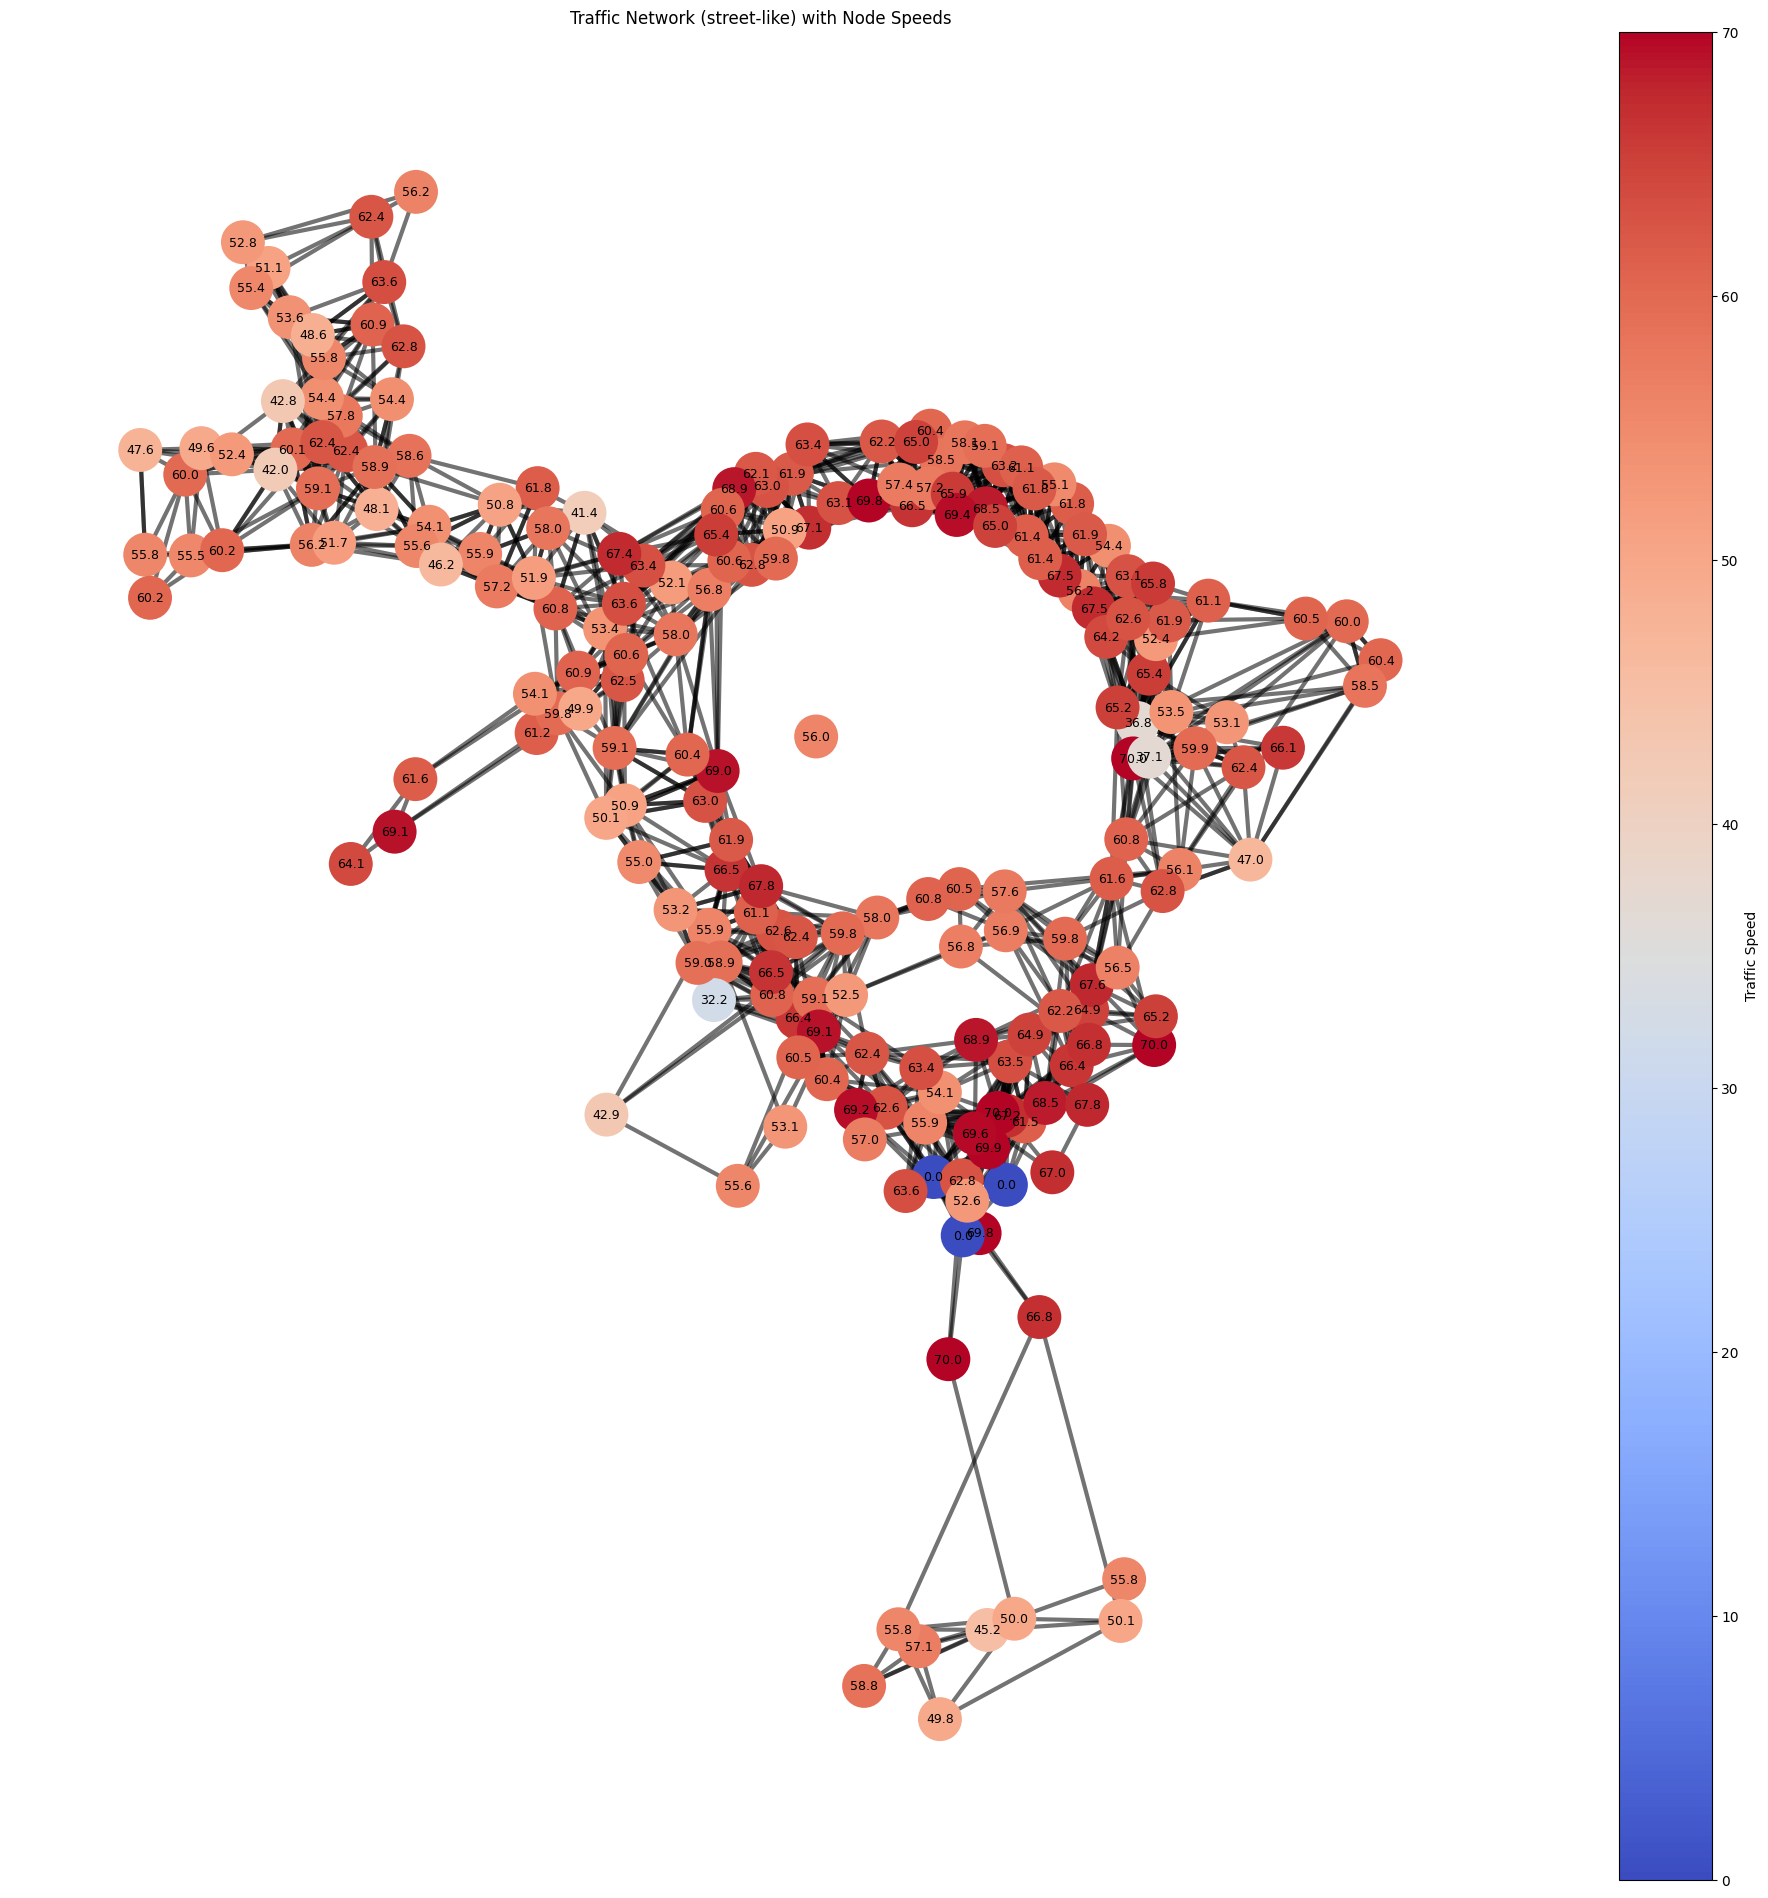

In [4]:

plot_traffic_graph_streetlike(
    DATA_DIR="./dataset",
    window_size=WINDOW_SIZE,
    window_index=0,
    label_k=25,
)


## Simple MLP

In [5]:
MLP_BATCH_SIZE=64
MLP_EPOCHS=50
MLP_LR=1e-3

train_loader, test_loader, X_train, Y_train, X_test, Y_test, static_node, static_edge, edge_index = load_and_prepare_data(INPUT_SEQ_LEN,MLP_BATCH_SIZE,DEVICE)
mlp_model,mlp_mae,mlp_mse,mlp_mape=mlp.train(train_loader, test_loader,MLP_EPOCHS,MLP_LR,device=DEVICE,INPUT_SEQ_LEN=INPUT_SEQ_LEN,OUTPUT_SEQ_LEN=OUTPUT_SEQ_LEN)
print(f"MLP Test MAE: {mlp_mae:.4f}")
print(f"MLP Test MSE: {mlp_mse:.4f}")
print(f"MLP Test MAPE: {mlp_mape:.4f}")

   - Final Data Shape: (2853, 36, 207, 1)
1
Epoch 001 | Train MAE: 27.9991 | Test MAE: 8.6046 | Test MSE: 234.9905 | Test MAPE: 17685060.82%
Epoch 002 | Train MAE: 6.4790 | Test MAE: 6.1921 | Test MSE: 177.9890 | Test MAPE: 14329893.79%
Epoch 003 | Train MAE: 5.3704 | Test MAE: 5.5495 | Test MSE: 164.0554 | Test MAPE: 11379111.50%
Epoch 004 | Train MAE: 5.1214 | Test MAE: 5.3989 | Test MSE: 162.6826 | Test MAPE: 10640549.39%
Epoch 005 | Train MAE: 5.0579 | Test MAE: 5.3288 | Test MSE: 161.1893 | Test MAPE: 10796172.39%
Epoch 006 | Train MAE: 5.0073 | Test MAE: 5.4107 | Test MSE: 159.0927 | Test MAPE: 10323999.32%
Epoch 007 | Train MAE: 5.0052 | Test MAE: 5.3456 | Test MSE: 162.2102 | Test MAPE: 10655832.68%
Epoch 008 | Train MAE: 4.9502 | Test MAE: 5.2327 | Test MSE: 161.3415 | Test MAPE: 10116282.82%
Epoch 009 | Train MAE: 4.9625 | Test MAE: 5.2979 | Test MSE: 157.2841 | Test MAPE: 10206406.68%
Epoch 010 | Train MAE: 4.9563 | Test MAE: 5.2111 | Test MSE: 158.3190 | Test MAPE: 10177485

## NLSTM

In [8]:
NLSTM_EPOCHS = 50
NLSTM_BATCH_SIZE = 64
NLSTM_LR = 1e-3
train_loader, test_loader, X_train, Y_train, X_test, Y_test, static_node, static_edge, edge_index = load_and_prepare_data(INPUT_SEQ_LEN,NLSTM_BATCH_SIZE,DEVICE)

nlstm_model = NLSTM.NLSTMBaseline(input_feat=1, hidden_size=10, num_layers=1, output_len=OUTPUT_SEQ_LEN).to(DEVICE)

# Train
nlstm_model,nlstm_mae,nlstm_mse,nlstm_mape=NLSTM.train_nlstm(nlstm_model, train_loader, test_loader,DEVICE, epochs=NLSTM_EPOCHS, lr=NLSTM_LR)

print(f"NLSTM Test MAE: {nlstm_mae:.4f}")
print(f"NLSTM Test MSE: {nlstm_mse:.4f}")
print(f"NLSTM Test MAPE: {nlstm_mape:.4f}") 

   - Final Data Shape: (2853, 36, 207, 1)
Epoch 001 | Train MAE: 53.9913 | Test MAE: 50.4484 | Test MSE: 3047.5098 | Test MAPE: 485082.06%
Epoch 002 | Train MAE: 52.8702 | Test MAE: 48.5880 | Test MSE: 2826.4445 | Test MAPE: 1564638.71%
Epoch 003 | Train MAE: 49.4301 | Test MAE: 43.8717 | Test MSE: 2314.1918 | Test MAPE: 3408681.48%
Epoch 004 | Train MAE: 43.0856 | Test MAE: 36.8068 | Test MSE: 1650.2251 | Test MAPE: 5282125.11%
Epoch 005 | Train MAE: 34.7159 | Test MAE: 28.2609 | Test MSE: 988.9925 | Test MAPE: 6471636.20%
Epoch 006 | Train MAE: 25.2605 | Test MAE: 19.3004 | Test MSE: 482.2178 | Test MAPE: 6955932.68%
Epoch 007 | Train MAE: 15.0822 | Test MAE: 9.6491 | Test MSE: 196.5200 | Test MAPE: 8173036.21%
Epoch 008 | Train MAE: 6.8771 | Test MAE: 5.3684 | Test MSE: 155.7548 | Test MAPE: 9017415.71%
Epoch 009 | Train MAE: 4.9919 | Test MAE: 5.1618 | Test MSE: 155.2021 | Test MAPE: 9047628.04%
Epoch 010 | Train MAE: 4.9419 | Test MAE: 5.1254 | Test MSE: 156.1707 | Test MAPE: 9088

In [ ]:


class TrafficLSTM(nn.Module):
    def __init__(self, num_nodes, hidden_dim=128):
        super().__init__()
        self.num_nodes = num_nodes
        self.lstm = nn.LSTM(
            input_size=num_nodes,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_nodes)

    def forward(self, x):
        # x: (B, T, N, 1)
        x = x.squeeze(-1)          # (B, T, N)
        out, _ = self.lstm(x)      # (B, T, H)
        out = out[:, -1, :]        # last timestep
        out = self.fc(out)         # (B, N)
        return out.unsqueeze(1)    # (B, 1, N)
    
(
    train_loader,
    test_loader,
    X_train,
    Y_train,
    X_test,
    Y_test,
    static_node,
    static_edge,
    edge_index
) = load_and_prepare_data()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_nodes = X_train.shape[2]
model = TrafficLSTM(num_nodes).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(200):
    model.train()
    total_loss = 0

    for X, Y in train_loader:
        X = X.to(device)
        Y = Y.to(device)

        # predict next step only
        pred = model(X)               # (B, 1, N)
        target = Y[:, 0, :, :]        # first future step

        loss = criterion(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
def mae(pred, target):
    return torch.mean(torch.abs(pred - target))

model.eval()
total_mae = 0
num_batches = 0

with torch.no_grad():
    for X, Y in test_loader:
        X = X.to(device)
        Y = Y.to(device)

        pred = model(X)                # (B, 1, N)
        target = Y[:, 0, :, :]         # first future timestep

        total_mae += mae(pred, target).item()
        num_batches += 1

average_mae = total_mae / num_batches
print(f"Test MAE: {average_mae:.4f}")

Loading data from ./dataset
!! Detected non-numeric data (timestamps). Cleaning automatically...
   - Dropping the first column (assuming it is the timestamp)...
   - Final Data Shape: (2853, 36, 207, 1)
torch.Size([2425, 24, 207, 1])
Data Ready.
Epoch 1, Loss: 3201.4368
Epoch 2, Loss: 2905.0220
Epoch 3, Loss: 2619.8305
Epoch 4, Loss: 2363.4128
Epoch 5, Loss: 2132.4009
Epoch 6, Loss: 1922.0465
Epoch 7, Loss: 1731.1308
Epoch 8, Loss: 1558.0014
Epoch 9, Loss: 1401.0627
Epoch 10, Loss: 1258.8694
Epoch 11, Loss: 1130.5327
Epoch 12, Loss: 1015.5142
Epoch 13, Loss: 912.5584
Epoch 14, Loss: 820.6527
Epoch 15, Loss: 739.2850
Epoch 16, Loss: 667.1906
Epoch 17, Loss: 603.5316
Epoch 18, Loss: 548.0564
Epoch 19, Loss: 499.7597
Epoch 20, Loss: 457.4185
Epoch 21, Loss: 421.0124
Epoch 22, Loss: 389.7916
Epoch 23, Loss: 363.0058
Epoch 24, Loss: 340.8762
Epoch 25, Loss: 321.3381
Epoch 26, Loss: 305.1278
Epoch 27, Loss: 291.5923
Epoch 28, Loss: 280.2640
Epoch 29, Loss: 270.9646
Epoch 30, Loss: 263.1867


## Seq2Seq

In [12]:
INPUT_SEQ_LEN = 24
OUTPUT_SEQ_LEN = 12
SEQ2SEQ_EPOCHS = 50
SEQ2SEQ_BATCH_SIZE = 64
SEQ2SEQ_LR = 1e-2 
HIDDEN_SIZE = 10    
NUM_LAYERS = 3      
SEQ2SEQ_TEACHER_FORCING = 0.5 


train_loader, test_loader, X_train, Y_train, X_test, Y_test, static_node, static_edge, edge_index = load_and_prepare_data(INPUT_SEQ_LEN,SEQ2SEQ_BATCH_SIZE,DEVICE)

model = Seq2Seq.Seq2SeqLSTM(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=0.0
).to(DEVICE)

model,seq2seq_mae,seq2seq_mse,seq2seq_mape=Seq2Seq.train(model, train_loader, test_loader, SEQ2SEQ_TEACHER_FORCING,DEVICE, SEQ2SEQ_EPOCHS, SEQ2SEQ_LR)
print("seq2seq Test MAE: {:.4f}".format(seq2seq_mae))
print("seq2seq Test MSE: {:.4f}".format(seq2seq_mse))
print("seq2seq Test MAPE: {:.4f}%".format(seq2seq_mape))

   - Final Data Shape: (2853, 36, 207, 1)
Epoch 001 | Train MAE: 51.8105 | Test MAE: 46.4611 | Test MSE: 2604.4058 | Test MAPE: 972670.85%
Epoch 002 | Train MAE: 47.3137 | Test MAE: 42.3662 | Test MSE: 2184.4809 | Test MAPE: 1771789.33%
Epoch 003 | Train MAE: 42.9420 | Test MAE: 38.4695 | Test MSE: 1818.2188 | Test MAPE: 2535075.32%
Epoch 004 | Train MAE: 38.9179 | Test MAE: 34.8732 | Test MSE: 1506.8522 | Test MAPE: 3356870.18%
Epoch 005 | Train MAE: 35.1195 | Test MAE: 31.4856 | Test MSE: 1240.1223 | Test MAPE: 3581692.12%
Epoch 006 | Train MAE: 31.4775 | Test MAE: 28.3356 | Test MSE: 1014.3427 | Test MAPE: 4049849.14%
Epoch 007 | Train MAE: 27.9274 | Test MAE: 25.2715 | Test MSE: 810.2874 | Test MAPE: 4702141.11%
Epoch 008 | Train MAE: 24.6024 | Test MAE: 22.3237 | Test MSE: 646.3741 | Test MAPE: 5124848.34%
Epoch 009 | Train MAE: 21.3463 | Test MAE: 19.4474 | Test MSE: 502.5837 | Test MAPE: 5776706.23%
Epoch 010 | Train MAE: 18.1557 | Test MAE: 16.8242 | Test MSE: 395.5469 | Test M

## DARNN


In [ ]:
INPUT_SEQ_LEN = 24
OUTPUT_SEQ_LEN = 12
EPOCHS = 50
BATCH_SIZE = 8
LR = 1e-3

HIDDEN_SIZE = 10   
NUM_LAYERS = 1    
TEACHER_FORCING = 1.0 

train_loader, test_loader, *_ = load_and_prepare_data(
    input_seq_length=INPUT_SEQ_LEN,
    batch_size=BATCH_SIZE,
    device=DEVICE,   
)

model, darnn_mae,darnn_mse,darnn_mape= DARNN.train_darnn(
    train_loader=train_loader,
    test_loader=test_loader,
    device=DEVICE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    lr=LR,
    epochs=EPOCHS,
    teacher_forcing=TEACHER_FORCING,
    grad_clip_norm=1.0,
) 

print("DARNN Test MAE: {:.4f}".format(darnn_mae))
print("DARNN Test MSE: {:.4f}".format(darnn_mse))
print("DARNN Test MAPE: {:.4f}%".format(darnn_mape))

   - Final Data Shape: (2853, 36, 207, 1)
Epoch 001 | Train MAE: 34.1496 | Test MAE: 10.3897 | Test MSE: 322.3349 | Test MAPE: 22938656.29%
Epoch 002 | Train MAE: 5.2351 | Test MAE: 8.2626 | Test MSE: 245.8000 | Test MAPE: 19259828.65%
Epoch 003 | Train MAE: 3.7749 | Test MAE: 8.2632 | Test MSE: 271.8999 | Test MAPE: 22492381.84%
Epoch 004 | Train MAE: 3.3139 | Test MAE: 7.6731 | Test MSE: 255.9019 | Test MAPE: 23184145.15%
Epoch 005 | Train MAE: 3.2218 | Test MAE: 7.3534 | Test MSE: 240.3994 | Test MAPE: 22836534.05%
Epoch 006 | Train MAE: 3.1405 | Test MAE: 7.3166 | Test MSE: 248.5086 | Test MAPE: 24577946.82%
Epoch 007 | Train MAE: 3.0626 | Test MAE: 7.3892 | Test MSE: 239.1042 | Test MAPE: 23749085.71%
Epoch 008 | Train MAE: 3.0475 | Test MAE: 7.1667 | Test MSE: 244.1345 | Test MAPE: 23986169.64%
Epoch 009 | Train MAE: 3.0090 | Test MAE: 7.3177 | Test MSE: 251.8737 | Test MAPE: 24189215.66%
Epoch 010 | Train MAE: 2.9999 | Test MAE: 7.2864 | Test MSE: 246.7734 | Test MAPE: 23553683.

## Paper



In [ ]:
INPUT_SEQ_LEN = 24
OUTPUT_SEQ_LEN = 12

HIDDEN_DIM = 64
LEARNING_RATE = 3e-4

TEACHER_FORCING =0
GRAD_CLIP_NORM = 1.0

SEQGNN_EPOCHS = 100
SEQGNN_BATCH_SIZE = 64

train_loader, test_loader, X_train, Y_train, X_test, Y_test, static_node, static_edge, edge_index = load_and_prepare_data(
    input_seq_length=INPUT_SEQ_LEN,
    batch_size=SEQGNN_BATCH_SIZE,
    device=DEVICE
)

model = SeqGNN.SeqGNN(
    num_static_node_feats=static_node.shape[1],
    num_static_edge_feats=static_edge.shape[1],
    hidden_dim=HIDDEN_DIM,
    input_seq_len=INPUT_SEQ_LEN,
    output_seq_len=OUTPUT_SEQ_LEN,
).to(DEVICE)


model, seqgnn_mae, seqgnn_mse, seqgnn_mape = SeqGNN.train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    static_node=static_node,
    static_edge=static_edge,
    edge_index=edge_index,
    device=DEVICE,
    learning_rate=LEARNING_RATE,
    epochs=SEQGNN_EPOCHS,
    # teacher_forcing=TEACHER_FORCING,
    grad_clip_norm=GRAD_CLIP_NORM,
)

In [ ]:

names = ["MLP", "NLSTM", "Seq2Seq", "DA-RNN", "SeqGNN"]
x = np.arange(len(names))
width = 0.6  # single bar per model

mae_values = [
    mlp_mae,
    nlstm_mae,
    seq2seq_mae,
    darnn_mae,
    5.08,       
]

mse_values = [
    mlp_mse,
    nlstm_mse,
    seq2seq_mse,
    darnn_mse,
    12.11**2,   
]


print(mae_values)
print(mse_values)


fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex="col")
(ax_mae_top, ax_mse_top), (ax_mae_bottom, ax_mse_bottom) = axes

def plot_zoom_and_full(ax_top, ax_bottom, values, title, ylabel, zoom_pad=0.03,color='blue'):
    # bars
    bars_top = ax_top.bar(x, values, width,color=color)
    ax_bottom.bar(x, values, width,color=color)

    # zoom limits (focus near the top)
    vmin = min(values)
    vmax = max(values)
    ax_top.set_ylim(vmin * (1 - zoom_pad), vmax * (1 + zoom_pad))

    # full scale from zero
    ax_bottom.set_ylim(0, vmax * 1.1)

    ax_top.set_title(title)
    ax_bottom.set_ylabel(ylabel)

    # show values at tips (top panel only)
    for bar in bars_top:
        h = bar.get_height()
        ax_top.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # clean look
    ax_top.grid(axis="y", alpha=0.2)
    ax_bottom.grid(axis="y", alpha=0.2)

# MAE panels
plot_zoom_and_full(
    ax_mae_top, ax_mae_bottom,
    mae_values,
    title="MAE ",
    ylabel="MAE"
    ,color='orange'
)

# MSE panels
plot_zoom_and_full(
    ax_mse_top, ax_mse_bottom,
    mse_values,
    title="MSE",
    ylabel="MSE"
)

# shared x labels on bottom row
ax_mae_bottom.set_xticks(x)
ax_mae_bottom.set_xticklabels(names, rotation=0)
ax_mse_bottom.set_xticks(x)
ax_mse_bottom.set_xticklabels(names, rotation=0)

plt.tight_layout()
plt.show()